In [1]:
EXP1 = "G6sulfur"     # subtrahend  (delta = EXP1 - EXP2)
EXP2 = "G6solar"
EXP3 = "SSP245"

target_lat=30

In [2]:
target_var = "ta"
# output_file = "VCorr_Temperature_G6sulfur_and_SSP245_2021-2050.nc"
output_file = "/gws/ssde/j25b/impose/bidyut/analysis_transient_data/VCorr_Temperature_G6sulfur_G6solar_SSP245_2100-2100_New.nc"


In [3]:
import numpy as np
import xarray as xr
import cftime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import xarray as xr
from pathlib import Path

import sys
import os

analysis_path = os.path.abspath("../20260112_Basic_Analysis")
sys.path.append(analysis_path)

import myfunctions as mf

#Package to suppress Python warnings
import warnings
warnings.filterwarnings("ignore")


import xesmf as xe
import xarray as xr
import numpy as np

# =========================
# Base CEDA paths
# =========================

CEDA_BASE = Path("/badc/cmip6/data/CMIP6")


#Model Names
MODELS = {
    # "UKESM1-0-LL":  {"institution": "MOHC",         "ensemble": "r1i1p1f2",  "grid": "gn",},
    # "CNRM-ESM2-1":  {"institution": "CNRM-CERFACS", "ensemble": "r1i1p1f2",  "grid": "gr",},
    # "MPI-ESM1-2-LR":{"institution": "MPI-M",        "ensemble": "r1i1p1f1",  "grid": "gn",},
    # "CESM2-WACCM":  {"institution": "NCAR",         "ensemble": "r1i1p1f1",  "grid": "gn",},
    "IPSL-CM6A-LR": {"institution": "IPSL",         "ensemble": "r1i1p1f1",  "grid": "gr",},
}


# =========================
# Experiment registry
# =========================

EXP_REGISTRY = {
    "piControl": {"project": "CMIP",        "scenario": "piControl"},
    "HIST":      {"project": "CMIP",        "scenario": "historical"},
    "SSP245":    {"project": "ScenarioMIP", "scenario": "ssp245"},
    "SSP585":    {"project": "ScenarioMIP", "scenario": "ssp585"},
    "G6solar":   {"project": "GeoMIP",      "scenario": "G6solar"},
    "G6sulfur":  {"project": "GeoMIP",      "scenario": "G6sulfur"},
}

# Built automatically from EXP1 and EXP2 and EXP3
EXPERIMENTS = {
    EXP1: EXP_REGISTRY[EXP1],
    EXP2: EXP_REGISTRY[EXP2],
    EXP3: EXP_REGISTRY[EXP3],
}

In [4]:
# ================================================================
# Utility: year-range label per experiment
# ================================================================

def _exp_year_label(exp_name):
    """Return the year-range suffix for an experiment name."""
    if exp_name in ("G6sulfur", "G6solar", "SSP245"):
        return "20212100"
    elif exp_name == "HIST":
        return "19212000"
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'. "
                         "Add it to _exp_year_label().")

def _time_slice(exp_name):
    """Return the (start, end) time slice strings for an experiment."""
    if exp_name in ("G6sulfur", "G6solar", "SSP245"):
        return ("2100-01-01", "2100-12")   # 80 years
    elif exp_name == "HIST":
        return ("1921-01-01", "2000-12")   # 80 years
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'.")


def roll_lon(da):
    """Roll longitude from 0-360 to -180-180."""
    da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180))
    return da.sortby('lon')


def regrid_to_common(da, target_lat=None, target_lon=None):
    """Regrid a DataArray to common lat/lon grid."""
    if target_lat is None:
        target_lat = np.arange(-50, 51, 2.5)
    elif isinstance(target_lat, tuple):
        target_lat = np.arange(target_lat[0], target_lat[1]+1, 2.5)
    elif isinstance(target_lat, (int, float)):
        target_lat = np.arange(-target_lat, target_lat+1, 2.5)

    if target_lon is None:
        target_lon = np.arange(0, 360, 2.5)  # always default to full lon
    elif isinstance(target_lon, tuple):
        target_lon = np.arange(target_lon[0], target_lon[1]+1, 2.5)

    ds_out = xr.Dataset({
        'lat': (['lat'], target_lat),
        'lon': (['lon'], target_lon)
    })

    # Handle both DataSet and DataArray cases
    if isinstance(da, xr.Dataset):
        ds_in = da
    else:
        ds_in = da.to_dataset(name='data')
        
    regridder = xe.Regridder(ds_in, ds_out, method='bilinear', reuse_weights=False)
    return regridder(da) 
    
def climatology_and_uncertainty(da_year, block_size=30):
    """
    da_year: DataArray with dimension 'year'
    Returns:
        clim_mean  : mean climatology (mean of 30-yr block means)
        clim_sd    : std dev across 30-yr block means
        block_means: DataArray of each 30-yr mean
    """

    n_years = da_year.sizes["year"]
    n_blocks = n_years // block_size

    # Trim excess years
    da_trim = da_year.isel(year=slice(0, n_blocks * block_size))

    # Create block index
    block = xr.DataArray(
        np.repeat(np.arange(n_blocks), block_size),
        dims="year",
        coords={"year": da_trim.year},
        name="block"
    )

    # Compute 30-year means
    block_means = (
        da_trim
        .groupby(block)
        .mean(dim="year")*86400
    )

    # Climatological mean (mean of 30-year means)
    clim_mean = block_means.mean(dim="block")

    # Spread across 30-year climatologies
    clim_sd = block_means.std(dim="block")

    return clim_mean, clim_sd, block_means


def load_model_data(base_path, model_name, scenario, mf):
    """
    Generic loader for model data based on model and scenario.

    Parameters
    ----------
    base_path : str or Path
        File path(s) to load
    model_name : str
    scenario : str
    mf : module
        Your module with open_files functions

    Returns
    -------
    xarray.Dataset
    """
    print(str(base_path))

    if model_name == "CESM2-WACCM":
        if scenario == "G6sulfur":
            return mf.open_files_CESM_G6sulfur(base_path)
        elif scenario == "ssp585":
            return mf.open_files_CESM_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))

    elif model_name == "IPSL-CM6A-LR":
        if scenario == "ssp585":
            return mf.open_files_IPSL_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))

    else:
        return mf.open_files(str(base_path))



def load_model_data_alt_path(base_path, project, institution, model_name, scenario, ensemble, grid, mf, var_name=None):
    """
    Generic loader for model data based on model and scenario.
    
    Parameters
    ----------
    base_path : str or Path
        File path(s) to load
    model_name : str
    scenario : str
    mf : module
        Your module with open_files functions
    var_name : str, optional
        Variable name (e.g., 'ua', 'va') to check for downloaded files
    
    Returns
    -------
    xarray.Dataset
    """
    print(str(base_path))
    
    # Check if files exist at base_path, otherwise look in downloaded directory
    base_path = Path(base_path)
    downloaded_base = Path("/gws/ssde/j25b/impose/bidyut/data")
    
    # if not base_path.exists() or not list(base_path.glob("*.nc")):
    if not any(base_path.glob("*.nc")):
        # Try downloaded directory
        if var_name:
            # --- special-case ensemble override ---
            if model_name == "CESM2-WACCM":
                ensemble = "r1i1p1f2" if scenario == "G6sulfur" else "r1i1p1f1"
            alt_path = (downloaded_base / project / institution / model_name / scenario / ensemble / "day" / 
                       var_name / grid / "latest")
            print(f"Alt path is: {alt_path}")
            if alt_path.exists():
                print(f"  → Using downloaded files at: {alt_path}")
                base_path = alt_path
    
    if model_name == "CESM2-WACCM":
        if scenario == "G6sulfur":
            return mf.open_files_CESM_G6sulfur(base_path)
        elif scenario == "ssp585":
            return mf.open_files_CESM_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))
    elif model_name == "IPSL-CM6A-LR":
        if scenario == "ssp585":
            return mf.open_files_IPSL_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))
    else:
        return mf.open_files(str(base_path))


def roll_and_regrid(varname):
    return roll_lon(regrid_to_common(varname, target_lat=30))

def roll_and_regrid_3d(ds, target_lat=30):
    """Roll and regrid, handling both 2D and 3D data."""
    ds = roll_lon(ds)
    
    if 'plev' in ds.dims or 'lev' in ds.dims:
        lev_dim = 'plev' if 'plev' in ds.dims else 'lev'
        regridded_levels = []
        for lev_val in ds[lev_dim].values:
            level_data = ds.sel({lev_dim: lev_val})
            regridded = regrid_to_common(level_data, target_lat=target_lat)
            regridded_levels.append(regridded)
        return xr.concat(regridded_levels, dim=lev_dim)
    else:
        return regrid_to_common(ds, target_lat=target_lat)

In [5]:
def _make_nan_vcorr(reference_ds, t_start, t_end):
    import numpy as np
    ta_ref  = reference_ds['ta']
    nlevels = len(ta_ref.plev)
    nlat    = len(ta_ref.lat)
    nlon    = len(ta_ref.lon)
    vcorr   = np.full((nlevels, nlevels, nlat, nlon), np.nan)
    return xr.Dataset(
        {'vcorr': (['plev_i', 'plev_j', 'lat', 'lon'], vcorr)},
        coords={
            'plev_i': ta_ref.plev.values,
            'plev_j': ta_ref.plev.values,
            'lat':    ta_ref.lat.values,
            'lon':    ta_ref.lon.values,
        },
        attrs={
            'description': 'All-NaN placeholder — source data unavailable',
            'time_slice':  f"{t_start} to {t_end}",
        }
    )

    

# def vertical_levelwise_correlation(ds_ta):
#     """
#     Compute vertical level-wise correlation for temperature anomalies (vectorized).
#     """
#     import xarray as xr
#     import numpy as np
    
#     ta = ds_ta['ta']
    
#     # Group by month to get monthly climatology
#     ta_monthly_clim = ta.groupby('time.month').mean('time')
    
#     # Calculate anomalies by removing monthly climatology
#     ta_anom = ta.groupby('time.month') - ta_monthly_clim
    
#     # Get dimensions
#     nmonths = 12
#     nlevels = len(ta.plev)
#     nlat = len(ta.lat)
#     nlon = len(ta.lon)
    
#     print(f"    Array dimensions: nlevels={nlevels}, nlat={nlat}, nlon={nlon}")
#     print(f"    Original data shape: {ta.shape}")
#     print(f"    Dimension order: {ta.dims}")
    
#     # Initialize output array: (month, plev_i, plev_j, lat, lon)
#     vcorr = np.full((nmonths, nlevels, nlevels, nlat, nlon), np.nan)
    
#     # Loop over each month
#     for imonth in range(1, 13):
#         print(f"    Processing month {imonth}/12", end='')
        
#         # Select data for this month
#         ta_month = ta_anom.sel(time=ta_anom.time.dt.month == imonth)
        
#         if len(ta_month.time) < 2:
#             print(f" - skipping (only {len(ta_month.time)} time steps)")
#             continue
        
#         ntime = len(ta_month.time)
#         print(f" ({ntime} time steps)")
        
#         # Ensure correct dimension order: (time, plev, lat, lon)
#         ta_month = ta_month.transpose('time', 'plev', 'lat', 'lon')
#         data = ta_month.values
        
#         print(f"      Data shape after transpose: {data.shape}")
        
#         # Reshape to (ntime, plev, nlat*nlon)
#         data_reshaped = data.reshape(ntime, nlevels, nlat * nlon)
        
#         # Loop over each pair of levels
#         for i in range(nlevels):  # ordinate (response)
#             for j in range(nlevels):  # abscissa (predictor)
#                 # Extract all spatial points for these two levels
#                 x = data_reshaped[:, j, :]  # (ntime, nlat*nlon)
#                 y = data_reshaped[:, i, :]  # (ntime, nlat*nlon)
                
#                 # Compute correlation coefficient for all grid points at once
#                 # Using numpy correlation formula: corr = cov(x,y) / (std(x) * std(y))
                
#                 # Remove time mean for each grid point
#                 x_mean = np.nanmean(x, axis=0, keepdims=True)
#                 y_mean = np.nanmean(y, axis=0, keepdims=True)
#                 x_anom = x - x_mean
#                 y_anom = y - y_mean
                
#                 # Compute covariance and standard deviations
#                 cov = np.nanmean(x_anom * y_anom, axis=0)
#                 std_x = np.nanstd(x, axis=0)
#                 std_y = np.nanstd(y, axis=0)
                
#                 # Compute correlation
#                 with np.errstate(divide='ignore', invalid='ignore'):
#                     corr = cov / (std_x * std_y)
                
#                 # Reshape back to (nlat, nlon) and store
#                 vcorr[imonth-1, i, j, :, :] = corr.reshape(nlat, nlon)
    
#     # Create output dataset
#     ds_out = xr.Dataset(
#         {
#             'vcorr': (['month', 'plev_i', 'plev_j', 'lat', 'lon'], vcorr)
#         },
#         coords={
#             'month': np.arange(1, 13),
#             'plev_i': ta.plev.values,
#             'plev_j': ta.plev.values,
#             'lat': ta.lat.values,
#             'lon': ta.lon.values
#         },
#         attrs={
#             'description': 'Vertical level-wise correlation of temperature anomalies',
#             'method': 'Pearson correlation between T anomalies at level i vs level j',
#             'reference': 'Following Lin & Emanuel (2024) PNAS doi:10.1073/pnas.2319228121',
#             'anomaly_base': 'Monthly climatology removed',
#             'note': 'Months with <2 time steps are skipped (NaN)'
#         }
#     )
    
#     return ds_out

def vertical_levelwise_correlation(ds_ta):
    """
    Compute vertical level-wise correlation for temperature anomalies.
    Anomaly = ta - ta.mean('time')
    Output: (time, plev_i, plev_j, lat, lon)
    One correlation matrix per time step, computed across spatial dimension.
    """
    import xarray as xr
    import numpy as np

    ta = ds_ta['ta']

    # Enforce dim order
    ta = ta.transpose('time', 'plev', 'lat', 'lon')

    # Anomaly: remove time mean only
    ta_anom = ta - ta.mean('time')

    ntime   = len(ta.time)
    nlevels = len(ta.plev)
    nlat    = len(ta.lat)
    nlon    = len(ta.lon)
    ngrid   = nlat * nlon

    print(f"    Dimensions: ntime={ntime}, nlevels={nlevels}, nlat={nlat}, nlon={nlon}")
    print(f"    Shape: {ta.shape},  dims: {ta.dims}")

    # Load into memory once: (ntime, nlevels, ngrid)
    data = ta_anom.values.reshape(ntime, nlevels, ngrid)

    if np.all(np.isnan(data)):
        print("    WARNING: all-NaN input — returning NaN array")
        vcorr = np.full((ntime, nlevels, nlevels, nlat, nlon), np.nan)
    else:
        vcorr = np.full((ntime, nlevels, nlevels, ngrid), np.nan)

        for i in range(nlevels):
            for j in range(nlevels):
                # x, y: (ntime, ngrid)
                x = data[:, j, :]
                y = data[:, i, :]

                if np.all(np.isnan(x)) or np.all(np.isnan(y)):
                    continue

                # At each time step t, correlate x[t,:] with y[t,:]
                # across the spatial (grid) dimension
                x_mean = np.nanmean(x, axis=1, keepdims=True)  # (ntime, 1)
                y_mean = np.nanmean(y, axis=1, keepdims=True)
                x_a    = x - x_mean   # (ntime, ngrid)
                y_a    = y - y_mean

                cov    = np.nanmean(x_a * y_a, axis=1)          # (ntime,)
                std_x  = np.nanstd(x, axis=1)                   # (ntime,)
                std_y  = np.nanstd(y, axis=1)

                with np.errstate(divide='ignore', invalid='ignore'):
                    corr = np.where(
                        (std_x == 0) | (std_y == 0),
                        np.nan,
                        cov / (std_x * std_y)
                    )                                            # (ntime,)

                # corr is (ntime,) — same value for all grid points
                # broadcast back to (ntime, ngrid)
                vcorr[:, i, j, :] = corr[:, np.newaxis]

            print(f"    Level {i+1}/{nlevels} done")

        vcorr = vcorr.reshape(ntime, nlevels, nlevels, nlat, nlon)
        vcorr = np.clip(vcorr, -1.0, 1.0)

    ds_out = xr.Dataset(
        {'vcorr': (['time', 'plev_i', 'plev_j', 'lat', 'lon'], vcorr)},
        coords={
            'time':   ta.time.values,
            'plev_i': ta.plev.values,
            'plev_j': ta.plev.values,
            'lat':    ta.lat.values,
            'lon':    ta.lon.values,
        },
        attrs={
            'description':  'Vertical level-wise correlation of temperature anomalies',
            'method':       'Pearson correlation across spatial dimension at each time step',
            'reference':    'Following Lin & Emanuel (2024) PNAS doi:10.1073/pnas.2319228121',
            'anomaly_base': 'Time mean removed (ta - ta.mean(time))',
            'time_scale':   'One correlation matrix per time step',
        }
    )
    return ds_out

In [6]:
"""
CORRELATION SECTION
"""
import os
if not os.path.exists(output_file):
    print('#'*40)
    print("File does not exist — running code")
    print('#'*40)
    # ================================================================
    # MAIN PROCESSING LOOP
    # ================================================================
    
    all_results = {}
    
    for model_name, model_meta in MODELS.items():
    
        vcorr_by_exp = {}
        seasonal_data = {}
    
        # ----------------------------
        # 1) LOAD DATA FOR A MODEL : ALL EXPERIMENTS
        # ----------------------------
        for exp, meta in EXPERIMENTS.items():
    
            # --- special-case ensemble override ---
            if model_name == "CESM2-WACCM":
                ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
            else:
                ensemble = model_meta["ensemble"]
    
            def make_base(vname):
                return (
                    CEDA_BASE
                    / meta["project"]
                    / model_meta["institution"]
                    / model_name
                    / meta["scenario"]
                    / ensemble
                    / "day"          # <-- changed from "Amon"
                    / vname
                    / model_meta["grid"]
                    / "latest"
                )
    
            base_ta = make_base("ta")
            
            ####### Handle ALTERNATE base paths ######
            ds_ta = load_model_data_alt_path(base_ta, meta["project"], model_meta["institution"], 
                                              model_name, meta["scenario"], 
                                              ensemble, model_meta["grid"], mf, "ta")
            # Slicing data
            t_start, t_end = _time_slice(exp)
            ds_sliced = ds_ta.sel(time=slice(t_start, t_end))
            
            # Roll and regrid
            ds_ta = roll_and_regrid_3d(ds_sliced, target_lat=30)
            
            print(f"  [{model_name}] {exp}: ta loaded {ds_ta.sizes['time']} time steps "  # <-- "months" → "time steps"
                  f"({ds_ta.time.values[0]} → {ds_ta.time.values[-1]})")
            
            # Calculate vertical correlation
            print(f"  [{model_name}] {exp}: Calculating vertical correlation")
            vcorr = vertical_levelwise_correlation(ds_ta)
            
            # Store for this experiment
            vcorr_by_exp[exp] = vcorr
    
        # After all experiments for this model
        all_results[model_name] = vcorr_by_exp
    
    
    # ================================================================
    # 5) CREATE OUTPUT NETCDF FILE
    # ================================================================
    
    model_list = []
    for model_name in all_results.keys():
        exp_list = []
        for exp in EXPERIMENTS.keys():
            if exp in all_results[model_name]:
                ds = all_results[model_name][exp]
                ds = ds.expand_dims({'experiment': [exp]})
                exp_list.append(ds)
        
        if exp_list:
            ds_model = xr.concat(exp_list, dim='experiment')
            ds_model = ds_model.expand_dims({'model': [model_name]})
            model_list.append(ds_model)
    
    ds_combined = xr.concat(model_list, dim='model')
    
    print(f"\nSaving to {output_file}...")
    ds_combined.to_netcdf(output_file)
    print(f"✓ Saved successfully!")
    print(f"  Dimensions: {dict(ds_combined.dims)}")
    print(f"  Variables: {list(ds_combined.data_vars)}")
else:
    print('#'*40)
    print(f"{output_file} already exists — skipping its computation")
    print('#'*40)

########################################
File does not exist — running code
########################################
/badc/cmip6/data/CMIP6/GeoMIP/IPSL/IPSL-CM6A-LR/G6sulfur/r1i1p1f1/day/ta/gr/latest
Alt path is: /gws/ssde/j25b/impose/bidyut/data/GeoMIP/IPSL/IPSL-CM6A-LR/G6sulfur/r1i1p1f1/day/ta/gr/latest
  → Using downloaded files at: /gws/ssde/j25b/impose/bidyut/data/GeoMIP/IPSL/IPSL-CM6A-LR/G6sulfur/r1i1p1f1/day/ta/gr/latest
  [IPSL-CM6A-LR] G6sulfur: ta loaded 365 time steps (2100-01-01 12:00:00 → 2100-12-31 12:00:00)
  [IPSL-CM6A-LR] G6sulfur: Calculating vertical correlation
    Dimensions: ntime=365, nlevels=8, nlat=25, nlon=144
    Shape: (365, 8, 25, 144),  dims: ('time', 'plev', 'lat', 'lon')
    Level 1/8 done
    Level 2/8 done
    Level 3/8 done
    Level 4/8 done
    Level 5/8 done
    Level 6/8 done
    Level 7/8 done
    Level 8/8 done
/badc/cmip6/data/CMIP6/GeoMIP/IPSL/IPSL-CM6A-LR/G6solar/r1i1p1f1/day/ta/gr/latest
Alt path is: /gws/ssde/j25b/impose/bidyut/data/GeoMIP/

# Plotting

In [7]:
# Load the dataset
ds_corr = xr.open_dataset(output_file)

In [8]:
print('ds_corr', ds_corr)

ds_corr <xarray.Dataset> Size: 2GB
Dimensions:     (model: 1, experiment: 3, time: 365, plev_i: 8, plev_j: 8,
                 lat: 25, lon: 144)
Coordinates:
  * model       (model) <U12 48B 'IPSL-CM6A-LR'
  * experiment  (experiment) <U8 96B 'G6sulfur' 'G6solar' 'SSP245'
  * time        (time) datetime64[ns] 3kB 2100-01-01T12:00:00 ... 2100-12-31T...
  * plev_i      (plev_i) float32 32B 1e+05 8.5e+04 7e+04 ... 1e+04 5e+03 1e+03
  * plev_j      (plev_j) float32 32B 1e+05 8.5e+04 7e+04 ... 1e+04 5e+03 1e+03
  * lat         (lat) float64 200B -30.0 -27.5 -25.0 -22.5 ... 25.0 27.5 30.0
  * lon         (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
Data variables:
    vcorr       (model, experiment, time, plev_i, plev_j, lat, lon) float64 2GB ...
Attributes:
    description:   Vertical level-wise correlation of temperature anomalies
    method:        Pearson correlation across spatial dimension at each time ...
    reference:     Following Lin & Emanuel (2024) PNAS doi:10.

In [9]:
# import matplotlib.pyplot as plt
# import numpy as np

# # select data
# da = ds_corr.vpatcorr.sel(
#     model='CESM2-WACCM',
#     experiment='SSP245',
#     month=[1,2,3,4,5,6,7,8,9,10,11,12]
# ).mean('month')

# plev = da.plev_i.values

# fig, ax = plt.subplots(figsize=(6, 5))

# cf = ax.contourf(
#     plev, plev, da.values,
#     levels=np.linspace(-1, 1, 81),
#     cmap='RdBu_r',
#     extend='both'
# )

# # ax.contour(
# #     plev, plev, da.values,
# #     levels=np.arange(-0.8, 1.0, 0.05),
# #     colors='k',
# #     linewidths=0.6
# # )

# ax.set_xscale('log')
# ax.set_yscale('log')
# ax.invert_xaxis()
# ax.invert_yaxis()

# ax.set_xlabel('Reference level (Pa)')
# ax.set_ylabel('Target level (Pa)')
# ax.set_title('Vertical pattern correlation (Annual, 30°S–30°N)')

# cbar = fig.colorbar(cf, ax=ax)
# cbar.set_label('Pattern correlation')

# plt.tight_layout()
# plt.show()

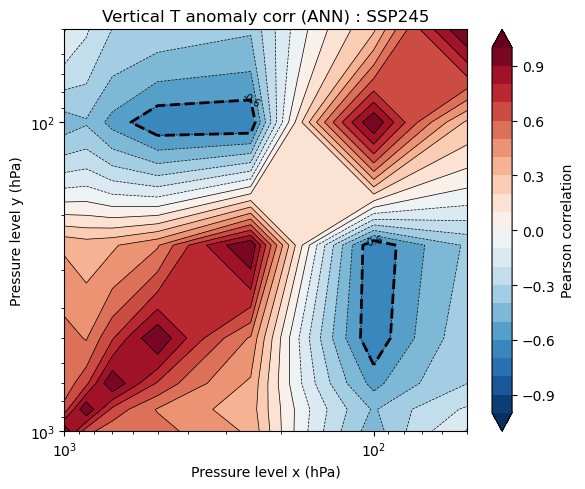

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# --- Selection ---
ds = ds_corr.sel(
    # model='UKESM1-0-LL',
    experiment='SSP245',
    lat=slice(-30, 30),     # paper uses tropics
).mean(dim='model')

# --- DJF mean ---
# ds_djf = ds.sel(month=[12, 1, 2]).vcorr.mean(dim=['month', 'lat', 'lon'])
ds_djf = ds.vcorr.mean(dim=['time', 'lat', 'lon']) # this is annual mean


# Pressure levels
plev = ds_djf.plev_i.values/100

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5))

cf = ax.contourf(
    plev, plev, ds_djf.values,
    levels=np.linspace(-1, 1, 21),
    cmap='RdBu_r',
    extend='both'
)

cs = ax.contour(
    plev, plev, ds_djf.values,
    levels=np.arange(-0.8, 1.0, 0.1),
    colors='k',
    linewidths=0.5
)
# ax.clabel(cs, cs.levels[0.6], inline=True, fontsize=7, fmt='%.1f')
# label only levels <= -0.6
ax.clabel(cs, levels=cs.levels[cs.levels <= -0.6], inline=True, fontsize=7, fmt='%.1f')

ax.contour(
    plev, plev, ds_djf.values,
    levels=[-0.6],
    colors='k',
    linewidths=2
)

# Log-pressure axis like meteorology
ax.set_xscale('log')
ax.set_yscale('log')
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_ylim(1000,50)
ax.set_xlim(1000,50)

ax.set_xlabel('Pressure level x (hPa)')
ax.set_ylabel('Pressure level y (hPa)')
ax.set_title('Vertical T anomaly corr (ANN) : SSP245')

cbar = fig.colorbar(cf, ax=ax)
cbar.set_label('Pearson correlation')

plt.tight_layout()
plt.show()

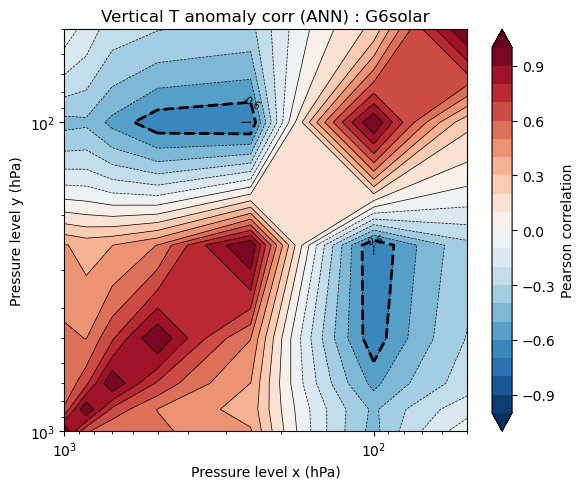

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# --- Selection ---
ds = ds_corr.sel(
    # model='UKESM1-0-LL',
    experiment='G6solar',
    lat=slice(-30, 30),     # paper uses tropics
).mean(dim='model')

# --- DJF mean ---
# ds_djf = ds.sel(month=[12, 1, 2]).vcorr.mean(dim=['month', 'lat', 'lon'])
ds_djf = ds.vcorr.mean(dim=['time', 'lat', 'lon']) # this is annual mean

# Pressure levels
plev = ds_djf.plev_i.values/100

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5))

cf = ax.contourf(
    plev, plev, ds_djf.values,
    levels=np.linspace(-1, 1, 21),
    cmap='RdBu_r',
    extend='both'
)

cs = ax.contour(
    plev, plev, ds_djf.values,
    levels=np.arange(-0.8, 1.0, 0.1),
    colors='k',
    linewidths=0.5
)
# label only levels <= -0.6
ax.clabel(cs, levels=cs.levels[cs.levels <= -0.6], inline=True, fontsize=7, fmt='%.1f')

ax.contour(
    plev, plev, ds_djf.values,
    levels=[-0.6],
    colors='k',
    linewidths=2
)

# Log-pressure axis like meteorology
ax.set_xscale('log')
ax.set_yscale('log')
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_ylim(1000,50)
ax.set_xlim(1000,50)

ax.set_xlabel('Pressure level x (hPa)')
ax.set_ylabel('Pressure level y (hPa)')
ax.set_title('Vertical T anomaly corr (ANN) : G6solar')

cbar = fig.colorbar(cf, ax=ax)
cbar.set_label('Pearson correlation')

plt.tight_layout()
plt.show()

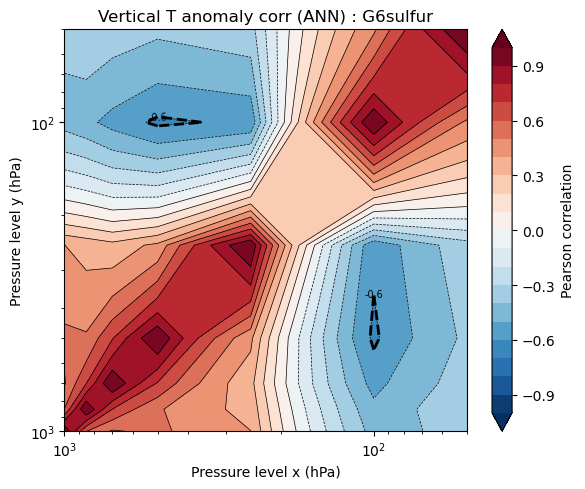

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# --- Selection ---
ds = ds_corr.sel(
    # model='UKESM1-0-LL',
    experiment='G6sulfur',
    lat=slice(-30, 30),     # paper uses tropics
).mean(dim='model')

# --- DJF mean ---
# ds_djf = ds.sel(month=[12, 1, 2]).vcorr.mean(dim=['month', 'lat', 'lon'])
ds_djf = ds.vcorr.mean(dim=['time', 'lat', 'lon']) # this is annual mean

# Pressure levels
plev = ds_djf.plev_i.values/100

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5))

cf = ax.contourf(
    plev, plev, ds_djf.values,
    levels=np.linspace(-1, 1, 21),
    cmap='RdBu_r',
    extend='both'
)

cs = ax.contour(
    plev, plev, ds_djf.values,
    levels=np.arange(-0.8, 1.0, 0.1),
    colors='k',
    linewidths=0.5
)
# label only levels <= -0.6
ax.clabel(cs, levels=cs.levels[cs.levels <= -0.6], inline=True, fontsize=7, fmt='%.1f')

ax.contour(
    plev, plev, ds_djf.values,
    levels=[-0.6],
    colors='k',
    linewidths=2
)

# Log-pressure axis like meteorology
ax.set_xscale('log')
ax.set_yscale('log')
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_ylim(1000,50)
ax.set_xlim(1000,50)

ax.set_xlabel('Pressure level x (hPa)')
ax.set_ylabel('Pressure level y (hPa)')
ax.set_title('Vertical T anomaly corr (ANN) : G6sulfur')

cbar = fig.colorbar(cf, ax=ax)
cbar.set_label('Pearson correlation')

plt.tight_layout()
plt.show()